In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from sklearn.preprocessing import StandardScaler
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_std = StandardScaler().fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.776210,1.828592,-0.293151,0.726273,-0.360668,-0.421860,0.669266,-1.164445,-0.785034,-1.101176,-0.964653,0.646616,-0.296907,-0.179158
1,-0.737256,-0.546869,-0.293151,-1.376893,-0.360668,2.370453,-1.494175,-1.164445,1.273829,0.105775,-0.964653,-1.098689,-0.763433,-0.587333
2,-0.158251,-0.546869,3.411211,-1.376893,-0.360668,-0.421860,0.669266,-1.164445,1.273829,0.705374,1.036642,-0.581431,0.191169,-0.192863
3,1.354953,-0.546869,-0.293151,-1.376893,-0.360668,2.370453,-1.494175,-1.164445,1.273829,0.550384,-0.964653,-1.499271,-0.705173,-0.594926
4,0.985240,-0.546869,-0.293151,-1.376893,-0.360668,2.370453,-1.494175,-1.164445,1.273829,1.233028,-0.964653,-1.032545,-0.613919,-0.540373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.024835,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,-0.785034,-1.101176,-0.964653,-0.312822,-0.615257,-0.488161
135,1.105290,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,-0.785034,-1.101176,1.036642,-0.704742,0.522969,-0.099128
136,-0.354794,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,1.273829,0.638406,-0.964653,0.535536,-0.413130,-0.282017
137,0.703351,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,1.273829,2.049005,1.036642,-0.642817,0.038162,-0.253362


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

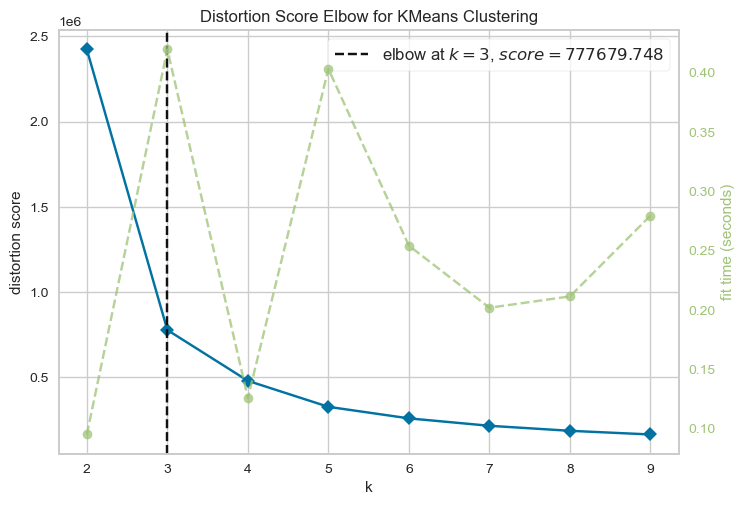

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 3 
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=3)

0
Most correlated column: larynx
Correlation coefficient: 1.007246376811598


1
Most correlated column: histgrade_high
Correlation coefficient: 1.0072463768115956


2
Most correlated column: SUVpeak
Correlation coefficient: 1.007246376811595




In [22]:
selected_features

['larynx', 'histgrade_high', 'SUVpeak']

In [23]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [24]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [44]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns

MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [45]:
X_new

,larynx,histgrade_high,SUVpeak
0,0,1,14.473272
1,1,0,5.044678
2,0,1,7.839043
3,1,0,2.880631
4,1,0,5.402006
...,...,...,...
134,0,1,9.290139
135,0,1,7.172883
136,0,1,13.873187
137,0,1,7.507419


In [46]:
X_new_std

,larynx,histgrade_high,SUVpeak
0,0,1,0.646616
1,1,0,-1.098689
2,0,1,-0.581431
3,1,0,-1.499271
4,1,0,-1.032545
...,...,...,...
134,0,1,-0.312822
135,0,1,-0.704742
136,0,1,0.535536
137,0,1,-0.642817


In [47]:
MAASTRO_new

,larynx,histgrade_high,SUVpeak
0,0,1,15.438583
1,0,0,8.829353
2,0,0,13.476123
3,1,1,8.632732
4,0,1,9.783954
...,...,...,...
94,1,0,31.338410
95,1,0,13.041604
96,0,1,8.944517
97,0,1,14.184236


In [48]:
MAASTRO_new_std

,larynx,histgrade_high,SUVpeak
0,0,1,0.825303
1,0,0,-0.398117
2,0,0,0.462036
3,1,1,-0.434513
4,0,1,-0.221413
...,...,...,...
94,1,0,3.768483
95,1,0,0.381603
96,0,1,-0.376799
97,0,1,0.593113


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [49]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:48:38,528] A new study created in memory with name: no-name-c05bcd87-3ce2-4bb8-956e-32409dccf892


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.45454545454545453
Fold 2 C-index: 0.5669642857142857
Fold 3 C-index: 0.6617647058823529


[I 2024-04-13 23:48:39,136] A new study created in memory with name: no-name-1a7d266e-dac0-49cc-8e2d-2409a0e13728


Fold 4 C-index: 0.759493670886076
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:48:39,054] Trial 0 finished with value: 0.6106193511051643 and parameters: {}. Best is trial 0 with value: 0.6106193511051643.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6106193511051643], datetime_start=datetime.datetime(2024, 4, 13, 23, 48, 38, 597293), datetime_complete=datetime.datetime(2024, 4, 13, 23, 48, 39, 53918), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6106193511051643


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23374885403052695
Fold 2 IBS: 0.2477816688856328
Fold 3 IBS: 0.19152948005790146
Fold 4 IBS: 0.18542320558843894
Fold 5 IBS: 0.2338707265279968
[I 2024-04-13 23:48:40,368] Trial 0 finished with value: 0.21847078701809938 and parameters: {}. Best is trial 0 with value: 0.21847078701809938.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21847078701809938], datetime_start=datetime.datetime(2024, 4, 13, 23, 48, 39, 208618), datetime_complete=datetime.datetime(2024, 4, 13, 23, 48, 40, 368209), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21847078701809938


In [50]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.611
train_ibs:  0.218


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.547
IBS score: 0.229


In [54]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [55]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [56]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:48:40,738] A new study created in memory with name: no-name-370b385a-3d1b-4cc4-82e0-032ac92c6322


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 23:48:41,224] A new study created in memory with name: no-name-1a1d9fcf-2d15-4d9c-b4f6-9e4e960b0855


Fold 1 C-index: 0.44805194805194803
Fold 2 C-index: 0.5334821428571429
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.5675105485232067
Fold 5 C-index: 0.6384976525821596
[I 2024-04-13 23:48:41,217] Trial 0 finished with value: 0.5600574780107346 and parameters: {}. Best is trial 0 with value: 0.5600574780107346.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5600574780107346], datetime_start=datetime.datetime(2024, 4, 13, 23, 48, 40, 938843), datetime_complete=datetime.datetime(2024, 4, 13, 23, 48, 41, 217333), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5600574780107346


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397652482174498
Fold 2 IBS: 0.22157791717788183
Fold 3 IBS: 0.20453594640282136
Fold 4 IBS: 0.22473803790560853
Fold 5 IBS: 0.21812431279488667
[I 2024-04-13 23:48:42,017] Trial 0 finished with value: 0.21659054782058867 and parameters: {}. Best is trial 0 with value: 0.21659054782058867.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054782058867], datetime_start=datetime.datetime(2024, 4, 13, 23, 48, 41, 385493), datetime_complete=datetime.datetime(2024, 4, 13, 23, 48, 42, 15659), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054782058867


In [57]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [58]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.56
train_ibs:  0.217


#### Test

In [59]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [60]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.574


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [61]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [62]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:48:42,588] A new study created in memory with name: no-name-2f6eae0b-3131-49ed-99ee-0d4bde9a13cd


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.45021645021645024
Fold 2 C-index: 0.5714285714285714
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.569620253164557


[I 2024-04-13 23:48:43,659] A new study created in memory with name: no-name-97169af8-301b-494c-9574-a78943e773ff


Fold 5 C-index: 0.6150234741784038
[I 2024-04-13 23:48:43,637] Trial 0 finished with value: 0.573610690974067 and parameters: {}. Best is trial 0 with value: 0.573610690974067.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.573610690974067], datetime_start=datetime.datetime(2024, 4, 13, 23, 48, 42, 680230), datetime_complete=datetime.datetime(2024, 4, 13, 23, 48, 43, 636919), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.573610690974067


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2335816281069383
Fold 2 IBS: 0.24738816961017998
Fold 3 IBS: 0.19178281105129014
Fold 4 IBS: 0.2212791598344567
Fold 5 IBS: 0.23300497605822576
[I 2024-04-13 23:48:45,087] Trial 0 finished with value: 0.22540734893221814 and parameters: {}. Best is trial 0 with value: 0.22540734893221814.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.22540734893221814], datetime_start=datetime.datetime(2024, 4, 13, 23, 48, 43, 699821), datetime_complete=datetime.datetime(2024, 4, 13, 23, 48, 45, 87036), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.22540734893221814


In [63]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [64]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.574
train_ibs:  0.225


#### Test

In [65]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [66]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.572


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.219


In [67]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [68]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:48:45,903] A new study created in memory with name: no-name-da28f7c9-f083-4640-ba56-0ecf9c4528aa


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.45021645021645024
Fold 2 C-index: 0.5714285714285714
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.569620253164557
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:48:46,845] Trial 0 finished with value: 0.5726717238379168 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5726717238379168.
Fold 1 C-index: 0.45021645021645024
Fold 2 C-index: 0.5669642857142857
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.569620253164557
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:48:47,946] Trial 1 finished with value: 0.5717788666950596 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.5726717238379168.
Fold 1 C-index: 0.45021645021645024
Fold 2 C-index: 0.5669642857142857
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.569620253164557
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:48:49,361] Trial 2 finished with value: 0.5717788666950596 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 1 C-index: 0.45021645021645024
Fold 2 C-index: 0.5714285714285714
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.569620253164557
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:49:09,342] Trial 24 finished with value: 0.5726717238379168 and parameters: {'l1_ratio': 0.7805647035680947}. Best is trial 6 with value: 0.573610690974067.
Fold 1 C-index: 0.45021645021645024
Fold 2 C-index: 0.5714285714285714
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.569620253164557
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:49:10,141] Trial 25 finished with value: 0.5726717238379168 and parameters: {'l1_ratio': 0.9368557715647121}. Best is trial 6 with value: 0.573610690974067.
Fold 1 C-index: 0.4588744588744589
Fold 2 C-index: 0.5446428571428571
Fold 3 C-index: 0.6323529411764706
Fold 4 C-index: 0.569620253164557
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:49:10,549] Trial 26 finished with value: 0.5716145339965513 and parameters: {'l1_ratio': 0.015423757551295547}.

Fold 1 C-index: 0.45021645021645024
Fold 2 C-index: 0.5714285714285714
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.569620253164557
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:49:29,508] Trial 48 finished with value: 0.5726717238379168 and parameters: {'l1_ratio': 0.7768768486379835}. Best is trial 6 with value: 0.573610690974067.
Fold 1 C-index: 0.45021645021645024
Fold 2 C-index: 0.5714285714285714
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.569620253164557
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:49:30,218] Trial 49 finished with value: 0.5726717238379168 and parameters: {'l1_ratio': 0.8386679916089912}. Best is trial 6 with value: 0.573610690974067.
Fold 1 C-index: 0.45021645021645024
Fold 2 C-index: 0.5714285714285714
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.569620253164557
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:49:30,955] Trial 50 finished with value: 0.5726717238379168 and parameters: {'l1_ratio': 0.945704027694845}. B

...

Fold 1 IBS: 0.23360431237974044
Fold 2 IBS: 0.24704966153149574
Fold 3 IBS: 0.19177659589413468
Fold 4 IBS: 0.2214179023886087
Fold 5 IBS: 0.23299363626029712
[I 2024-04-13 23:50:19,806] Trial 0 finished with value: 0.2253684216908553 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.2253684216908553.
Fold 1 IBS: 0.23365029782629335
Fold 2 IBS: 0.24664582793056475
Fold 3 IBS: 0.1917488997124643
Fold 4 IBS: 0.22194988004074445
Fold 5 IBS: 0.23286881152905697
[I 2024-04-13 23:50:21,598] Trial 1 finished with value: 0.22537274340782476 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.2253684216908553.
Fold 1 IBS: 0.23366110495068032
Fold 2 IBS: 0.24653967639006363
Fold 3 IBS: 0.19174505154867674
Fold 4 IBS: 0.22213590585137838
Fold 5 IBS: 0.23292833204225788
[I 2024-04-13 23:50:23,804] Trial 2 finished with value: 0.2254020141566114 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.225368421690855

Fold 2 IBS: 0.22194230030881607
Fold 3 IBS: 0.20407382668922258
Fold 4 IBS: 0.2233041807193622
Fold 5 IBS: 0.2328388734601432
[I 2024-04-13 23:50:46,036] Trial 25 finished with value: 0.21955612729166543 and parameters: {'l1_ratio': 0.06475136573424659}. Best is trial 18 with value: 0.21646591309223498.
Fold 1 IBS: 0.2336737450416165
Fold 2 IBS: 0.24640433032694745
Fold 3 IBS: 0.1917416199466774
Fold 4 IBS: 0.22243523911124777
Fold 5 IBS: 0.23288964028960504
[I 2024-04-13 23:50:46,961] Trial 26 finished with value: 0.22542891494321884 and parameters: {'l1_ratio': 0.16185399957944996}. Best is trial 18 with value: 0.21646591309223498.
Fold 1 IBS: 0.23365795763343497
Fold 2 IBS: 0.24658718398781462
Fold 3 IBS: 0.191755632484856
Fold 4 IBS: 0.2219824995654291
Fold 5 IBS: 0.23292005707460905
[I 2024-04-13 23:50:47,788] Trial 27 finished with value: 0.22538066614922875 and parameters: {'l1_ratio': 0.2743289465581149}. Best is trial 18 with value: 0.21646591309223498.
Fold 1 IBS: 0.214770962

Fold 1 IBS: 0.23362981993434948
Fold 2 IBS: 0.2467638165735277
Fold 3 IBS: 0.19175585148831215
Fold 4 IBS: 0.22168985370310174
Fold 5 IBS: 0.23292807477005792
[I 2024-04-13 23:51:11,369] Trial 50 finished with value: 0.2253534832938698 and parameters: {'l1_ratio': 0.41653985858071785}. Best is trial 42 with value: 0.21643619091914.
Fold 1 IBS: 0.21494614635392917
Fold 2 IBS: 0.22171171229011066
Fold 3 IBS: 0.20425128505050535
Fold 4 IBS: 0.2237816439712677
Fold 5 IBS: 0.21752289269515154
[I 2024-04-13 23:51:11,925] Trial 51 finished with value: 0.21644273607219291 and parameters: {'l1_ratio': 0.03617776249477511}. Best is trial 42 with value: 0.21643619091914.
Fold 1 IBS: 0.21496716505684563
Fold 2 IBS: 0.22171731689209637
Fold 3 IBS: 0.20424555707464448
Fold 4 IBS: 0.22376490190645995
Fold 5 IBS: 0.21751371213399
[I 2024-04-13 23:51:12,371] Trial 52 finished with value: 0.2164417306128073 and parameters: {'l1_ratio': 0.03702089793435445}. Best is trial 42 with value: 0.21643619091914.

Fold 1 IBS: 0.23368957376528518
Fold 2 IBS: 0.2463074626630968
Fold 3 IBS: 0.2038969876957594
Fold 4 IBS: 0.22290438050954928
Fold 5 IBS: 0.23288102145330086
[I 2024-04-13 23:51:44,667] Trial 75 finished with value: 0.22793588521739833 and parameters: {'l1_ratio': 0.09901365815189192}. Best is trial 60 with value: 0.21643565917845864.
Fold 1 IBS: 0.21526648869513001
Fold 2 IBS: 0.22180828082747747
Fold 3 IBS: 0.20416550966153876
Fold 4 IBS: 0.22354046522947926
Fold 5 IBS: 0.23285037578583684
[I 2024-04-13 23:51:45,532] Trial 76 finished with value: 0.21952622403989247 and parameters: {'l1_ratio': 0.04933781199900923}. Best is trial 60 with value: 0.21643565917845864.
Fold 1 IBS: 0.23367188918673296
Fold 2 IBS: 0.2464232192730027
Fold 3 IBS: 0.19175152901567513
Fold 4 IBS: 0.22227438957599904
Fold 5 IBS: 0.23287313765342288
[I 2024-04-13 23:51:46,677] Trial 77 finished with value: 0.22539883294096655 and parameters: {'l1_ratio': 0.19328346899350535}. Best is trial 60 with value: 0.21643

Fold 5 IBS: 0.23291134608061817
[I 2024-04-13 23:52:11,309] Trial 99 finished with value: 0.22542160792493643 and parameters: {'l1_ratio': 0.18280024182863655}. Best is trial 60 with value: 0.21643565917845864.


* Best trial for IBS: 
 FrozenTrial(number=60, state=TrialState.COMPLETE, values=[0.21643565917845864], datetime_start=datetime.datetime(2024, 4, 13, 23, 51, 22, 919136), datetime_complete=datetime.datetime(2024, 4, 13, 23, 51, 23, 747633), params={'l1_ratio': 0.04585349711698398}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=60, value=None)


* Best Score for IBS: 
 0.21643565917845864


In [69]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [70]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.574
train_ibs:  0.216


#### Test

In [71]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [72]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.980766121964777)

test_cindex : 0.572


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.04585349711698398)

test_ibs:  0.221


In [73]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [74]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:52:12,039] A new study created in memory with name: no-name-4a213b12-1cf6-4bf4-8b47-4862c7c2ed88


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.39826839826839827
Fold 2 C-index: 0.6294642857142857
Fold 3 C-index: 0.5416666666666666
Fold 4 C-index: 0.5949367088607594
Fold 5 C-index: 0.5258215962441315
[I 2024-04-13 23:52:25,852] Trial 0 finished with value: 0.5380315311508483 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5380315311508483.
Fold 1 C-index: 0.3722943722943723
Fold 2 C-index: 0.421875
Fold 3 C-index: 0.5931372549019608
Fold 4 C-index: 0.689873417721519
Fold 5 C-index: 0.5352112676056338
[I 2024-04-13 23:52:36,152] Trial 1 finished with value: 0.5224782625046972 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_featu

Fold 5 C-index: 0.636150234741784
[I 2024-04-13 23:55:25,509] Trial 15 finished with value: 0.5983213214903945 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 8, 'min_samples_leaf': 16, 'max_depth': 7, 'n_estimators': 79, 'oob_score': True, 'max_samples': 0.8511647045899534, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.10131211790757674, 'warm_start': True}. Best is trial 14 with value: 0.6000341694279943.
Fold 1 C-index: 0.4025974025974026
Fold 2 C-index: 0.6629464285714286
Fold 3 C-index: 0.5759803921568627
Fold 4 C-index: 0.7025316455696202
Fold 5 C-index: 0.5845070422535211
[I 2024-04-13 23:55:26,806] Trial 16 finished with value: 0.585712582229767 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 2, 'min_samples_leaf': 18, 'max_depth': 7, 'n_estimators': 12, 'oob_score': True, 'max_samples': 0.878258248844428, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.11081447908272878, 'warm_start': True}. Best is trial 14 with value: 0.6000341694279943.
F

Fold 1 C-index: 0.4199134199134199
Fold 2 C-index: 0.6473214285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6265822784810127
Fold 5 C-index: 0.5845070422535211
[I 2024-04-13 23:56:14,482] Trial 30 finished with value: 0.5831158142360333 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 6, 'min_samples_leaf': 17, 'max_depth': 14, 'n_estimators': 212, 'oob_score': True, 'max_samples': 0.6786167449016399, 'max_features': None, 'min_weight_fraction_leaf': 0.22480342649610294, 'warm_start': True}. Best is trial 29 with value: 0.6041641580455908.
Fold 1 C-index: 0.36147186147186144
Fold 2 C-index: 0.6830357142857143
Fold 3 C-index: 0.625
Fold 4 C-index: 0.6751054852320675
Fold 5 C-index: 0.6666666666666666
[I 2024-04-13 23:56:18,869] Trial 31 finished with value: 0.6022559455312619 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 14, 'max_depth': 4, 'n_estimators': 150, 'oob_score': True, 'max_samples': 0.9309062002883736, 'max_feature

...

Fold 4 IBS: 0.22485475642787395
Fold 5 IBS: 0.21743657775687325
[I 2024-04-14 00:33:08,723] Trial 31 finished with value: 0.21634462607890598 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 13, 'min_samples_leaf': 19, 'max_depth': 16, 'n_estimators': 248, 'oob_score': True, 'max_samples': 0.15693095325678008, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.24152690054739573}. Best is trial 15 with value: 0.21624700411917724.
Fold 1 IBS: 0.21397986895767881
Fold 2 IBS: 0.2206112160317524
Fold 3 IBS: 0.2051755414740527
Fold 4 IBS: 0.22455701419368237
Fold 5 IBS: 0.21793955878328608
[I 2024-04-14 00:33:17,566] Trial 32 finished with value: 0.21645263988809046 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 13, 'min_samples_leaf': 20, 'max_depth': 16, 'n_estimators': 166, 'oob_score': True, 'max_samples': 0.23461355417853963, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.25575276920056406}. Best is trial 15 with value: 0.21624700411917724.
Fold 1 IBS: 

Fold 1 IBS: 0.21392283856055402
Fold 2 IBS: 0.22063843752261786
Fold 3 IBS: 0.2052965848585141
Fold 4 IBS: 0.22505617667738154
Fold 5 IBS: 0.21710257031150337
[I 2024-04-14 00:35:34,183] Trial 47 finished with value: 0.21640332158611417 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 14, 'min_samples_leaf': 17, 'max_depth': 13, 'n_estimators': 216, 'oob_score': True, 'max_samples': 0.12491884860269041, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.30340817398476577}. Best is trial 15 with value: 0.21624700411917724.
Fold 1 IBS: 0.21874153709531133
Fold 2 IBS: 0.22027795456388388
Fold 3 IBS: 0.20369266400114883
Fold 4 IBS: 0.22277334675423643
Fold 5 IBS: 0.2196150948774618
[I 2024-04-14 00:35:48,933] Trial 48 finished with value: 0.21702011945840843 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 11, 'min_samples_leaf': 6, 'max_depth': 15, 'n_estimators': 277, 'oob_score': True, 'max_samples': 0.9878828376623068, 'max_features': 'log2', 'min_weight_fracti

Fold 5 IBS: 0.2177883352699284
[I 2024-04-14 00:36:37,270] Trial 62 finished with value: 0.21629196271962398 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 16, 'min_samples_leaf': 19, 'max_depth': 3, 'n_estimators': 61, 'oob_score': False, 'max_samples': 0.2150931494030446, 'max_features': None, 'min_weight_fraction_leaf': 0.1791646144192856}. Best is trial 61 with value: 0.21611055045619715.
Fold 1 IBS: 0.21402919295625203
Fold 2 IBS: 0.22034651930471366
Fold 3 IBS: 0.20459436089885208
Fold 4 IBS: 0.22532871538092178
Fold 5 IBS: 0.21759597923225144
[I 2024-04-14 00:36:42,111] Trial 63 finished with value: 0.2163789535545982 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 19, 'min_samples_leaf': 20, 'max_depth': 4, 'n_estimators': 102, 'oob_score': False, 'max_samples': 0.12269057173317272, 'max_features': None, 'min_weight_fraction_leaf': 0.19651054202010515}. Best is trial 61 with value: 0.21611055045619715.
Fold 1 IBS: 0.21397619161529588
Fold 2 IBS: 0.2214851

Fold 1 IBS: 0.21403091836321106
Fold 2 IBS: 0.22276439454896668
Fold 3 IBS: 0.20429899225404047
Fold 4 IBS: 0.22665264316925993
Fold 5 IBS: 0.22168004550071949
[I 2024-04-14 00:37:26,200] Trial 78 finished with value: 0.2178853987672395 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 17, 'min_samples_leaf': 3, 'max_depth': 5, 'n_estimators': 17, 'oob_score': False, 'max_samples': 0.24359296554119841, 'max_features': None, 'min_weight_fraction_leaf': 0.25546511470065086}. Best is trial 61 with value: 0.21611055045619715.
Fold 1 IBS: 0.21397347259675192
Fold 2 IBS: 0.2201617591316743
Fold 3 IBS: 0.20467778537187575
Fold 4 IBS: 0.22485277989339647
Fold 5 IBS: 0.21740202484989138
[I 2024-04-14 00:37:30,123] Trial 79 finished with value: 0.21621356436871797 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 18, 'min_samples_leaf': 19, 'max_depth': 7, 'n_estimators': 93, 'oob_score': False, 'max_samples': 0.17272995210418754, 'max_features': None, 'min_weight_fraction_leaf

Fold 1 IBS: 0.2140051055405482
Fold 2 IBS: 0.22007637388545803
Fold 3 IBS: 0.20462020359979555
Fold 4 IBS: 0.2250966835004479
Fold 5 IBS: 0.21757277218347762
[I 2024-04-14 00:38:35,822] Trial 94 finished with value: 0.21627422774194546 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 18, 'min_samples_leaf': 7, 'max_depth': 6, 'n_estimators': 98, 'oob_score': False, 'max_samples': 0.12109040929892183, 'max_features': None, 'min_weight_fraction_leaf': 0.23201712852313522}. Best is trial 61 with value: 0.21611055045619715.
Fold 1 IBS: 0.2139451926845148
Fold 2 IBS: 0.22139071106709277
Fold 3 IBS: 0.20469675802631596
Fold 4 IBS: 0.2248318570497485
Fold 5 IBS: 0.21861903642137073
[I 2024-04-14 00:38:41,637] Trial 95 finished with value: 0.21669671104980853 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'max_depth': 2, 'n_estimators': 112, 'oob_score': False, 'max_samples': 0.3259650636721622, 'max_features': None, 'min_weight_fraction_leaf':

In [75]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [76]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.703
train_ibs:  0.216


#### Test

In [77]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [78]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=11, max_leaf_nodes=18,
                     max_samples=0.5454951325375041, min_samples_leaf=1,
                     min_samples_split=9,
                     min_weight_fraction_leaf=0.0006660329676803165,
                     n_estimators=472, random_state=123, warm_start=True)

test_cindex:  0.567


RandomSurvivalForest(max_depth=5, max_features=None, max_leaf_nodes=16,
                     max_samples=0.11753122811130205, min_samples_leaf=20,
                     min_samples_split=8,
                     min_weight_fraction_leaf=0.19635364343594605,
                     n_estimators=56, random_state=123)

test_ibs:  0.222


In [79]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [80]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:39:14,620] A new study created in memory with name: no-name-733371bf-be26-4270-8676-78e114f4f6b9


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.45670995670995673
Fold 2 C-index: 0.6227678571428571
Fold 3 C-index: 0.6495098039215687
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6056338028169014
[I 2024-04-14 00:39:18,775] Trial 0 finished with value: 0.6230424275781724 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6230424275781724.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:39:27,420] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.246842548825153

Fold 2 C-index: 0.6272321428571429
Fold 3 C-index: 0.6323529411764706
Fold 4 C-index: 0.7911392405063291
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 00:40:51,441] Trial 15 finished with value: 0.6248512852482117 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 9, 'min_samples_leaf': 6, 'max_depth': 11, 'n_estimators': 362, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.9163782618183121, 'min_weight_fraction_leaf': 0.07436726243220565}. Best is trial 15 with value: 0.6248512852482117.
Fold 1 C-index: 0.42424242424242425
Fold 2 C-index: 0.6651785714285714
Fold 3 C-index: 0.5906862745098039
Fold 4 C-index: 0.6286919831223629
Fold 5 C-index: 0.5657276995305164
[I 2024-04-14 00:40:54,496] Trial 16 finished with value: 0.5749053905667358 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 9, 'min_samples_leaf': 6, 'max_depth': 9, 'n_estimators': 277, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.89699542

Fold 1 C-index: 0.4653679653679654
Fold 2 C-index: 0.6183035714285714
Fold 3 C-index: 0.6495098039215687
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6032863849765259
[I 2024-04-14 00:42:13,811] Trial 30 finished with value: 0.6234116885988419 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 2, 'min_samples_leaf': 2, 'max_depth': 16, 'n_estimators': 397, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7210779691747853, 'min_weight_fraction_leaf': 0.10851074456160753}. Best is trial 25 with value: 0.6336872951987972.
Fold 1 C-index: 0.474025974025974
Fold 2 C-index: 0.6183035714285714
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 00:42:19,833] Trial 31 finished with value: 0.6340660125660663 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 4, 'min_samples_leaf': 3, 'max_depth': 19, 'n_estimators': 407, 'oob_score': False, 'warm_start': True, 'max_feature

...

Fold 1 IBS: 0.21655466719570376
Fold 2 IBS: 0.21648347763421452
Fold 3 IBS: 0.20461044736354286
Fold 4 IBS: 0.21965252517313208
Fold 5 IBS: 0.2191819699310069
[I 2024-04-14 00:52:31,353] Trial 30 finished with value: 0.21529661745952003 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 14, 'min_samples_leaf': 15, 'max_depth': 8, 'n_estimators': 274, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.9188916885060139, 'min_weight_fraction_leaf': 0.20241101766143602}. Best is trial 11 with value: 0.21522788179163177.
Fold 1 IBS: 0.21669794894419042
Fold 2 IBS: 0.21678370265059452
Fold 3 IBS: 0.204639569898474
Fold 4 IBS: 0.2194423180787471
Fold 5 IBS: 0.21918619338606066
[I 2024-04-14 00:52:40,132] Trial 31 finished with value: 0.21534994659161333 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 14, 'min_samples_leaf': 15, 'max_depth': 8, 'n_estimators': 291, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 

Fold 1 IBS: 0.2162998315204704
Fold 2 IBS: 0.22414428641944714
Fold 3 IBS: 0.2014627769617829
Fold 4 IBS: 0.21821117078377494
Fold 5 IBS: 0.21986557272489365
[I 2024-04-14 00:55:13,712] Trial 45 finished with value: 0.21599672768207384 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 18, 'min_samples_leaf': 11, 'max_depth': 10, 'n_estimators': 446, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.924733511563999, 'min_weight_fraction_leaf': 0.006006030687203504}. Best is trial 11 with value: 0.21522788179163177.
Fold 1 IBS: 0.21549104511356595
Fold 2 IBS: 0.21794869174490014
Fold 3 IBS: 0.20473314054554945
Fold 4 IBS: 0.2223970740361272
Fold 5 IBS: 0.21936527313153537
[I 2024-04-14 00:55:20,325] Trial 46 finished with value: 0.2159870449143356 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5, 'n_estimators': 220, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.87

Fold 1 IBS: 0.21557216859884168
Fold 2 IBS: 0.21951845319553281
Fold 3 IBS: 0.2033957903024152
Fold 4 IBS: 0.21873107357562732
Fold 5 IBS: 0.2193540518242419
[I 2024-04-14 00:57:41,534] Trial 60 finished with value: 0.21531430749933178 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 17, 'min_samples_leaf': 13, 'max_depth': 1, 'n_estimators': 321, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.9145009056636586, 'min_weight_fraction_leaf': 0.04603788952425106}. Best is trial 11 with value: 0.21522788179163177.
Fold 1 IBS: 0.21648805001657506
Fold 2 IBS: 0.21581769507583984
Fold 3 IBS: 0.20494501405904808
Fold 4 IBS: 0.21980350515739372
Fold 5 IBS: 0.2193095571559961
[I 2024-04-14 00:57:52,004] Trial 61 finished with value: 0.21527276429297054 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 20, 'min_samples_leaf': 17, 'max_depth': 9, 'n_estimators': 378, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.973

Fold 1 IBS: 0.21620675911869341
Fold 2 IBS: 0.2165464391552601
Fold 3 IBS: 0.20484389883465481
Fold 4 IBS: 0.2209784313349249
Fold 5 IBS: 0.21946461646847873
[I 2024-04-14 01:00:34,996] Trial 75 finished with value: 0.21560802898240242 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 19, 'max_depth': 8, 'n_estimators': 357, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.9753293703053094, 'min_weight_fraction_leaf': 0.09965104801557817}. Best is trial 65 with value: 0.21508545858442202.
Fold 1 IBS: 0.22021259502119914
Fold 2 IBS: 0.2361768886996566
Fold 3 IBS: 0.19774073730980782
Fold 4 IBS: 0.2046687992965607
Fold 5 IBS: 0.23028359085803238
[I 2024-04-14 01:00:46,646] Trial 76 finished with value: 0.2178165222370513 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 320, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.9386998244

Fold 1 IBS: 0.2164263918576331
Fold 2 IBS: 0.2176906620089059
Fold 3 IBS: 0.2042468493384511
Fold 4 IBS: 0.2185544243182095
Fold 5 IBS: 0.21923817802509082
[I 2024-04-14 01:03:45,600] Trial 90 finished with value: 0.2152313011096581 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'max_depth': 7, 'n_estimators': 327, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.9312685747358955, 'min_weight_fraction_leaf': 0.1959146396333301}. Best is trial 78 with value: 0.21506778106634608.
Fold 1 IBS: 0.21640526681769312
Fold 2 IBS: 0.21823743988220756
Fold 3 IBS: 0.20397962346437118
Fold 4 IBS: 0.21853345687254322
Fold 5 IBS: 0.2192444641311804
[I 2024-04-14 01:03:56,299] Trial 91 finished with value: 0.2152800502335991 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 8, 'max_depth': 7, 'n_estimators': 329, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.92807645021400

In [81]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [82]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.655
train_ibs:  0.215


#### Test

In [83]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [84]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=5, max_features=1, max_leaf_nodes=16,
                   max_samples=0.9932133556786273, min_samples_split=3,
                   min_weight_fraction_leaf=0.028354576951528, n_estimators=150,
                   oob_score=True, random_state=123, warm_start=True)

C-index score: 0.544


ExtraSurvivalTrees(max_depth=5, max_features=1, max_leaf_nodes=18,
                   max_samples=0.999930764152109, min_samples_leaf=16,
                   min_samples_split=15,
                   min_weight_fraction_leaf=0.13845052233002883,
                   n_estimators=346, oob_score=True, random_state=123)

IBS: 0.219


In [85]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [86]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 01:05:32,946] A new study created in memory with name: no-name-a5af5796-4c76-4305-94a6-4fd1c700e592


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:06:24,770] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:06:54,611] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:15:33,200] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.402356635584068, 'learning_rate': 0.04320515007344335, 'dropout_rate': 0.4821375662037144, 'n_estimators': 338, 'criterion': 'friedman_mse', 'ccp_alpha': 5.782673919726945, 'min_weight_fraction_leaf': 0.3780093996731174, 'max_features': 1, 'min_impurity_decrease': 4.1224286247713165e-05, 'validation_fraction': 0.3705130702856921, 'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 16, 'max_depth': 14}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:16:36,924] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.8084735022381804, 'learning_rate': 0.051554368700984315, 'dropout_rate': 0.7600297296847041, 'n_estimators': 485, 'criterion': 'friedman_mse', 'ccp_alpha': 1.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:23:38,019] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.7290419373338021, 'learning_rate': 0.008509588429086327, 'dropout_rate': 0.8441717101825217, 'n_estimators': 96, 'criterion': 'squared_error', 'ccp_alpha': 4.233740780727753, 'min_weight_fraction_leaf': 0.32029463020494575, 'max_features': 1, 'min_impurity_decrease': 3.23815069163876e-06, 'validation_fraction': 0.3886651085109431, 'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 14, 'max_depth': 6}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:23:49,319] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.835623033509183, 'learning_rate': 0.0441170168532854, 'dropout_rate': 0.661659879615144, 'n_estimators': 170, 'criterion': 'friedman_mse', 'ccp_alpha': 5.46231

...

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560958
[I 2024-04-14 03:12:34,974] Trial 45 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.9423581992051376, 'learning_rate': 0.00870079568001468, 'dropout_rate': 0.9243730341297751, 'n_estimators': 331, 'criterion': 'squared_error', 'ccp_alpha': 7.04773521781731, 'min_weight_fraction_leaf': 0.19866658441469065, 'max_features': 0.1, 'min_impurity_decrease': 0.0017836769072294195, 'validation_fraction': 0.001686507347744337, 'min_samples_split': 7, 'max_leaf_nodes': 18, 'min_samples_leaf': 15, 'max_depth': 9}. Best is trial 14 with value: 0.21659054862241583.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 03:12:41,877] Trial 46 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7601306318519188, 'learning_rate': 0.0142173906851729

Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 03:14:51,358] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9470345333627548, 'learning_rate': 0.020520871416557077, 'dropout_rate': 0.7546956719538825, 'n_estimators': 135, 'criterion': 'squared_error', 'ccp_alpha': 4.693918481824396, 'min_weight_fraction_leaf': 0.2487463324044564, 'max_features': 'log2', 'min_impurity_decrease': 9.495778915269051e-07, 'validation_fraction': 0.6682715637714014, 'min_samples_split': 9, 'max_leaf_nodes': 17, 'min_samples_leaf': 8, 'max_depth': 11}. Best is trial 14 with value: 0.21659054862241583.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 03:14:59,376] Trial 57 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7915280524929411, 'learning_rate': 0.012137837778053249, 'dropout_rate': 0.7227843

Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 03:18:44,890] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8302433734032149, 'learning_rate': 0.006781737784397601, 'dropout_rate': 0.7453329148042112, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 4.017596992694904, 'min_weight_fraction_leaf': 0.2674964870273292, 'max_features': 0.1, 'min_impurity_decrease': 7.418918022704639e-05, 'validation_fraction': 0.8000570654422638, 'min_samples_split': 7, 'max_leaf_nodes': 9, 'min_samples_leaf': 17, 'max_depth': 1}. Best is trial 14 with value: 0.21659054862241583.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 03:18:57,537] Trial 68 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.9209957004165874, 'learning_rate': 0.01062423601337367, 'dropout_rate': 0.6383415244088105, 'n_estimators': 189, 'crite

Fold 1 IBS: 0.2140716674853475
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453778102824233
Fold 4 IBS: 0.22471818218022066
Fold 5 IBS: 0.2181379703523294
[I 2024-04-14 03:20:09,169] Trial 79 finished with value: 0.21660870364656387 and parameters: {'subsample': 0.37577625196815084, 'learning_rate': 0.048880003857177695, 'dropout_rate': 0.5395271493420024, 'n_estimators': 30, 'criterion': 'friedman_mse', 'ccp_alpha': 0.03087187707929262, 'min_weight_fraction_leaf': 0.21901875474116986, 'max_features': 'log2', 'min_impurity_decrease': 3.1261071962202034e-07, 'validation_fraction': 0.1671589307842662, 'min_samples_split': 11, 'max_leaf_nodes': 9, 'min_samples_leaf': 18, 'max_depth': 3}. Best is trial 14 with value: 0.21659054862241583.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609557
[I 2024-04-14 03:20:24,969] Trial 80 finished with value: 0.21659054862241583 and parameters: 

Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 03:24:14,248] Trial 90 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7306151097727858, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.516411590157757, 'n_estimators': 288, 'criterion': 'friedman_mse', 'ccp_alpha': 5.467834683516639, 'min_weight_fraction_leaf': 0.29457624096966484, 'max_features': 0.1, 'min_impurity_decrease': 2.131078882275086e-06, 'validation_fraction': 0.1954775635807845, 'min_samples_split': 6, 'max_leaf_nodes': 19, 'min_samples_leaf': 18, 'max_depth': 9}. Best is trial 14 with value: 0.21659054862241583.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-14 03:24:34,000] Trial 91 finished with value: 0.21659054862241586 and parameters: {'subsam

In [87]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [88]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.5
train_ibs:  0.217


#### Test

In [89]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [90]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=9.807641983846155,
                                 dropout_rate=0.3041663082077828,
                                 learning_rate=0.02932779416008757,
                                 max_depth=11, max_leaf_nodes=5,
                                 min_impurity_decrease=2.4449249473284515e-05,
                                 min_samples_leaf=11, min_samples_split=5,
                                 min_weight_fraction_leaf=0.34241486929243165,
                                 n_estimators=276, random_state=123,
                                 subsample=0.7268222670380755,
                                 validation_fraction=0.7379954057320357)

C-index score: 0.5


GradientBoostingSurvivalAnalysis(ccp_alpha=1.9769893642798817,
                                 dropout_rate=0.7600297296847041,
                                 learning_rate=0.051554368700984315,
                                 max_depth=5, max_features='log2',
                                 max_leaf_nodes=8,
                                 min_impurity_decrease=1.3593599611215348e-06,
                                 min_samples_leaf=20, min_samples_split=7,
                                 min_weight_fraction_leaf=0.3599117851340217,
                                 n_estimators=485, random_state=123,
                                 subsample=0.8084735022381804,
                                 validation_fraction=0.7750966442838666)

IBS: 0.221


In [91]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [92]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 03:28:33,749] A new study created in memory with name: no-name-ced295cd-5e54-447b-a816-bf0c6d6be1d1


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4588744588744589
Fold 2 C-index: 0.45089285714285715
Fold 3 C-index: 0.5833333333333334
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.6338028169014085
[I 2024-04-14 03:28:36,368] Trial 0 finished with value: 0.5528068535879643 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5528068535879643.
Fold 1 C-index: 0.4588744588744589
Fold 2 C-index: 0.45089285714285715
Fold 3 C-index: 0.5833333333333334
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6197183098591549
[I 2024-04-14 03:28:56,778] Trial 1 finished with value: 0.5508338340360537 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5528068535879643.
Fold 1 C-index: 0.45454545454545453
Fold 2 C-index: 0.5357142857142857
Fold 3 C-index: 0.6666666666666666
Fo

Fold 1 C-index: 0.4329004329004329
Fold 2 C-index: 0.5714285714285714
Fold 3 C-index: 0.6666666666666666
Fold 4 C-index: 0.6877637130801688
Fold 5 C-index: 0.6244131455399061
[I 2024-04-14 03:31:38,635] Trial 19 finished with value: 0.5966345059231491 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.19696537183520607, 'n_estimators': 341, 'learning_rate': 0.0014892065469161303}. Best is trial 4 with value: 0.6031631966713977.
Fold 1 C-index: 0.45454545454545453
Fold 2 C-index: 0.5401785714285714
Fold 3 C-index: 0.6666666666666666
Fold 4 C-index: 0.7088607594936709
Fold 5 C-index: 0.6197183098591549
[I 2024-04-14 03:31:55,511] Trial 20 finished with value: 0.5979939523987037 and parameters: {'subsample': 0.28937249949982, 'dropout_rate': 0.4383363080708982, 'n_estimators': 430, 'learning_rate': 0.040913220186367553}. Best is trial 4 with value: 0.6031631966713977.
Fold 1 C-index: 0.4458874458874459
Fold 2 C-index: 0.5714285714285714
Fold 3 C-index: 0.6666666666666666

Fold 1 C-index: 0.45454545454545453
Fold 2 C-index: 0.5357142857142857
Fold 3 C-index: 0.6666666666666666
Fold 4 C-index: 0.6540084388185654
Fold 5 C-index: 0.6150234741784038
[I 2024-04-14 03:34:08,109] Trial 38 finished with value: 0.5851916639846753 and parameters: {'subsample': 0.5602770145716328, 'dropout_rate': 0.3629835328379081, 'n_estimators': 167, 'learning_rate': 0.07288612365177065}. Best is trial 4 with value: 0.6031631966713977.
Fold 1 C-index: 0.4458874458874459
Fold 2 C-index: 0.5625
Fold 3 C-index: 0.6666666666666666
Fold 4 C-index: 0.7257383966244726
Fold 5 C-index: 0.6197183098591549
[I 2024-04-14 03:34:10,418] Trial 39 finished with value: 0.604102163807548 and parameters: {'subsample': 0.21104727246564636, 'dropout_rate': 0.48831311354868023, 'n_estimators': 99, 'learning_rate': 0.05598015324329953}. Best is trial 39 with value: 0.604102163807548.
Fold 1 C-index: 0.44155844155844154
Fold 2 C-index: 0.5357142857142857
Fold 3 C-index: 0.6862745098039216
Fold 4 C-inde

...

Fold 2 IBS: 0.31403860377068205
Fold 3 IBS: 0.1856667860872163
Fold 4 IBS: 0.20813431659283343
Fold 5 IBS: 0.2650040247631296
[I 2024-04-14 03:41:00,399] Trial 19 finished with value: 0.2501462324648933 and parameters: {'subsample': 0.650899739648275, 'dropout_rate': 0.9954484919483726, 'n_estimators': 400, 'learning_rate': 0.011730584939170362}. Best is trial 15 with value: 0.21662475095130876.
Fold 1 IBS: 0.23097873687286766
Fold 2 IBS: 0.24716895531426444
Fold 3 IBS: 0.1961072811301361
Fold 4 IBS: 0.21787729907866227
Fold 5 IBS: 0.22606508253214674
[I 2024-04-14 03:41:01,774] Trial 20 finished with value: 0.22363947098561546 and parameters: {'subsample': 0.9010126869682862, 'dropout_rate': 0.6173032374045795, 'n_estimators': 67, 'learning_rate': 0.0257290746252228}. Best is trial 15 with value: 0.21662475095130876.
Fold 1 IBS: 0.2140873980596061
Fold 2 IBS: 0.2217688546347539
Fold 3 IBS: 0.204440986490764
Fold 4 IBS: 0.2246566822442027
Fold 5 IBS: 0.21814062526004846
[I 2024-04-14 0

Fold 3 IBS: 0.19305154053195092
Fold 4 IBS: 0.19010433068051122
Fold 5 IBS: 0.34591266512766494
[I 2024-04-14 03:41:35,643] Trial 38 finished with value: 0.29837054050289985 and parameters: {'subsample': 0.5872963751371887, 'dropout_rate': 0.13272164755980653, 'n_estimators': 158, 'learning_rate': 0.0802388198308747}. Best is trial 22 with value: 0.2165944188893619.
Fold 1 IBS: 0.23089417710114415
Fold 2 IBS: 0.24656690010112456
Fold 3 IBS: 0.19548995913641762
Fold 4 IBS: 0.21898424529717855
Fold 5 IBS: 0.2257644256185679
[I 2024-04-14 03:41:44,631] Trial 39 finished with value: 0.22353994145088657 and parameters: {'subsample': 0.9436047786916928, 'dropout_rate': 0.6881141432789704, 'n_estimators': 309, 'learning_rate': 0.005489826361343792}. Best is trial 22 with value: 0.2165944188893619.
Fold 1 IBS: 0.23228086278692722
Fold 2 IBS: 0.24943720119620874
Fold 3 IBS: 0.19480127966671013
Fold 4 IBS: 0.2168419191612448
Fold 5 IBS: 0.22607245548159302
[I 2024-04-14 03:41:46,385] Trial 40 fi

Fold 4 IBS: 0.22364070724154025
Fold 5 IBS: 0.21806214315321926
[I 2024-04-14 03:42:23,225] Trial 57 finished with value: 0.2166829551529986 and parameters: {'subsample': 0.13165605060453595, 'dropout_rate': 0.8850025073755081, 'n_estimators': 14, 'learning_rate': 0.013889254076353235}. Best is trial 49 with value: 0.21659345040022351.
Fold 1 IBS: 0.37064069879100253
Fold 2 IBS: 0.4518906988984234
Fold 3 IBS: 0.2514374465144452
Fold 4 IBS: 0.2709805787535179
Fold 5 IBS: 0.39193170197958543
[I 2024-04-14 03:42:41,605] Trial 58 finished with value: 0.34737622498739484 and parameters: {'subsample': 0.865146645306422, 'dropout_rate': 0.8153328144022535, 'n_estimators': 498, 'learning_rate': 0.0693354289548123}. Best is trial 49 with value: 0.21659345040022351.
Fold 1 IBS: 0.25282870740368374
Fold 2 IBS: 0.30721931531443175
Fold 3 IBS: 0.18708691182186937
Fold 4 IBS: 0.20498746121498773
Fold 5 IBS: 0.23274335793137024
[I 2024-04-14 03:42:42,974] Trial 59 finished with value: 0.2369731507372

Fold 5 IBS: 0.21987134011265652
[I 2024-04-14 03:43:01,154] Trial 76 finished with value: 0.21841811305600095 and parameters: {'subsample': 0.7476078535713924, 'dropout_rate': 0.449350356472916, 'n_estimators': 66, 'learning_rate': 0.01098489429042545}. Best is trial 73 with value: 0.2165927109579898.
Fold 1 IBS: 0.24415644949992393
Fold 2 IBS: 0.2648141670783739
Fold 3 IBS: 0.191562389795756
Fold 4 IBS: 0.2150619829621913
Fold 5 IBS: 0.2353746770380102
[I 2024-04-14 03:43:12,565] Trial 77 finished with value: 0.2301939332748511 and parameters: {'subsample': 0.7875768506268902, 'dropout_rate': 0.4954203980228134, 'n_estimators': 337, 'learning_rate': 0.007738559280748048}. Best is trial 73 with value: 0.2165927109579898.
Fold 1 IBS: 0.21510720495305313
Fold 2 IBS: 0.2237123545361827
Fold 3 IBS: 0.20369385084618438
Fold 4 IBS: 0.2237517196881465
Fold 5 IBS: 0.21832431752349077
[I 2024-04-14 03:43:13,418] Trial 78 finished with value: 0.2169178895094115 and parameters: {'subsample': 0.58

Fold 1 IBS: 0.2144110056546686
Fold 2 IBS: 0.222332481030781
Fold 3 IBS: 0.20415995935919543
Fold 4 IBS: 0.22448118442135934
Fold 5 IBS: 0.2181902312082472
[I 2024-04-14 03:43:30,947] Trial 96 finished with value: 0.21671497233485032 and parameters: {'subsample': 0.8631927528964066, 'dropout_rate': 0.22406527504369078, 'n_estimators': 13, 'learning_rate': 0.005075612213502388}. Best is trial 73 with value: 0.2165927109579898.
Fold 1 IBS: 0.2150838715481678
Fold 2 IBS: 0.22342117248507126
Fold 3 IBS: 0.20365663925871516
Fold 4 IBS: 0.22398514115405777
Fold 5 IBS: 0.21833683870793644
[I 2024-04-14 03:43:31,799] Trial 97 finished with value: 0.2168967326307897 and parameters: {'subsample': 0.7762425436428736, 'dropout_rate': 0.42468430630591375, 'n_estimators': 25, 'learning_rate': 0.006530251244595304}. Best is trial 73 with value: 0.2165927109579898.
Fold 1 IBS: 0.24187107203149286
Fold 2 IBS: 0.2624838859806308
Fold 3 IBS: 0.19166140812810228
Fold 4 IBS: 0.2159007842944632
Fold 5 IBS: 

In [93]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [94]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.609
train_ibs:  0.217


#### Test

In [95]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [96]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.30099270866841327,
                                              learning_rate=0.09670463986956042,
                                              n_estimators=220,
                                              random_state=123,
                                              subsample=0.21694460077868424)

C-index score: 0.545


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.4035184555692438,
                                              learning_rate=0.0012079815371274958,
                                              n_estimators=1, random_state=123,
                                              subsample=0.8426073346269455)

IBS: 0.221


In [97]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [98]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.703,1.0
ExtraSurvivalTrees,0.655,2.0
CoxPH,0.611,3.0
ComponentwiseGradientBoosting,0.609,4.0
CoxLasso,0.574,5.5
CoxElastic,0.574,5.5
CoxRidge,0.560,7.0
GradientBoosting,0.500,8.0


In [99]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.215,1.0
CoxElastic,0.216,2.5
Randomsurvivalforest,0.216,2.5
CoxRidge,0.217,5.0
GradientBoosting,0.217,5.0
ComponentwiseGradientBoosting,0.217,5.0
CoxPH,0.218,7.0
CoxLasso,0.225,8.0


In [100]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxRidge,0.574,1.0
CoxLasso,0.572,2.5
CoxElastic,0.572,2.5
Randomsurvivalforest,0.567,4.0
CoxPH,0.547,5.0
ComponentwiseGradientBoosting,0.545,6.0
ExtraSurvivalTrees,0.544,7.0
GradientBoosting,0.500,8.0


In [101]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxLasso,0.219,1.5
ExtraSurvivalTrees,0.219,1.5
CoxRidge,0.221,4.5
CoxElastic,0.221,4.5
GradientBoosting,0.221,4.5
ComponentwiseGradientBoosting,0.221,4.5
Randomsurvivalforest,0.222,7.0
CoxPH,0.229,8.0


In [102]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/standard/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

modified_file_names = ['d1_os_standard_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [103]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
